#**Imports:**

In [100]:
import numpy as np
from scipy.optimize import minimize_scalar
import cvxpy as cp
import matplotlib.pyplot as plt
import math
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import os

#**Core Controller Functions:**

In [101]:
def CVaR(X, alpha):

  x = np.atleast_1d(np.asarray(X, dtype=float))

  def f(z):

    numerator = np.maximum(x - z, 0.0)
    denominator = 1 - alpha

    fraction = numerator / denominator

    inside = z + fraction

    E = np.mean(inside)

    return E

  res = minimize_scalar(f)

  return res.fun



In [102]:
def h_ij(x_i, x_j, r_safe):

  d = x_i - x_j

  d_sqrd = d @ d

  return d_sqrd - (r_safe)**2

In [103]:
def CVaR_uncertainty_term(x_i, x_j, eps_mean_i, eps_cov_i, eps_mean_j, eps_cov_j, alpha, num_samples):

  diff = x_i - x_j

  e_i_samples = np.random.multivariate_normal(eps_mean_i, eps_cov_i, size=num_samples)
  e_j_samples = np.random.multivariate_normal(eps_mean_j, eps_cov_j, size=num_samples)

  proj_samples = (e_i_samples - e_j_samples) @ diff

  return CVaR(proj_samples, alpha)

In [104]:
def L_ij(i, j, x, u, eps_mean, eps_cov, gamma, r_safe, alpha, num_samples, c=100.0):

  diff = x[i] - x[j]

  first_term = -2 * (diff @ (u[i] - u[j]))

  second_term = -2 * CVaR_uncertainty_term(x[i], x[j], eps_mean[i], eps_cov[i], eps_mean[j], eps_cov[j], alpha, num_samples)

  third_term = -gamma * h_ij(x[i], x[j], r_safe)

  total = first_term + second_term + third_term + c

  return total




In [105]:

def R_i(i, N, x, u, eps_mean, eps_cov, gamma, r_safe, alpha, num_samples):
  total = 0.0

  for j in range(N):

    if i == j:
      continue

    total += L_ij(i, j, x, u, eps_mean, eps_cov, gamma, r_safe, alpha, num_samples)

  return total

In [106]:
def w_i(Ri, Rj):

  wi = Rj / (Ri + Rj)

  return wi

In [107]:
def A(x_i, x_j):

  a = -2 * (x_i - x_j)

  return a

In [108]:
def b(x_i, x_j, eps_mean_i, eps_cov_i, eps_mean_j, eps_cov_j, gamma, r_safe, alpha, num_samples):

  B = gamma * h_ij(x_i, x_j, r_safe)

  cvar_uncertainty = 2 * CVaR_uncertainty_term(x_i, x_j, eps_mean_i, eps_cov_i, eps_mean_j, eps_cov_j, alpha, num_samples)

  B += cvar_uncertainty

  return B

In [109]:


def solve_minimum_deviation_control(u_nom_i, A, b, u_min, u_max):
    u = cp.Variable(2)

    objective = cp.Minimize(cp.sum_squares(u - u_nom_i))
    constraints = [
        A @ u <= b,
        u >= u_min,
        u <= u_max,
    ]

    problem = cp.Problem(objective, constraints)

    solvers_to_try = [cp.OSQP, cp.SCS]

    for solver in solvers_to_try:
        try:
            problem.solve(solver=solver, warm_start=True, verbose=False)

            if problem.status in ("optimal", "optimal_inaccurate"):
                u_star = np.array(u.value).reshape(2,)
                return u_star, True

        except cp.error.SolverError:
            continue

    return None, False

# **Scenario 1 Code:**

In [110]:
def nominal_accel(x, v, goals, kp, kv):

  return kp * (goals - x) - kv * v


In [111]:
def simulate_ramp_merge(x_init, v_init, seed=None):

  if seed is not None:
    np.random.seed(seed)

  x = x_init.copy()

  v = v_init.copy()

  goals = np.array([
      [20.0,  0.0],   # Goal for vehicle 1 beyond merge zone
      [20.0,  0.0],   # Goal for vehicle 2 beyond merge zone
      [20.0, 0.0]    # Goal for vehicl 3 beyond merge zone
  ], dtype=float)

  gamma = 0.1

  r_safe = 1.5

  alpha = 0.95

  eps_mean = np.array([
      [ 0.05, -0.02],
      [-0.03,  0.04],
      [ 0.01, -0.05]
  ], dtype=float)

  eps_cov = np.array([
      [[0.01, 0.0], [0.0, 0.01]],
      [[0.01, 0.0], [0.0, 0.01]],
      [[0.01, 0.0], [0.0, 0.01]]
  ], dtype=float)

  num_samples = 30


  N = 3          # number of agents
  T = 100        # run controller for 200 timesteps

  dt = 0.1 # timestep
  u_min = -2.0
  u_max = 2.0

  # Keep track of data to review later
  x_hist = [x.copy()]
  v_hist = [v.copy()]
  u_hist = []
  risk_hist = []

  # History of euclidean distances
  dist_hist = {
      "d12": [],
      "d13": [],
      "d23": [],
  }

  # History of responsibilty shares
  weight_hist = {
      "w13": [],
      "w31": [],
      "w12": [],
      "w21": [],
      "w23": [],
      "w32": [],
  }

  for _ in range(T):

    u_nom = nominal_accel(x, v, goals, 0.25, 1.0)

    u_next = np.zeros((N, 2), dtype=float)

    risks = np.array([R_i(i, N, x, v, eps_mean, eps_cov, gamma, r_safe, alpha, num_samples) for i in range(N)], dtype=float)

    risk_hist.append(risks.copy())

    dist_hist["d12"].append(np.linalg.norm(x[0] - x[1]))
    dist_hist["d13"].append(np.linalg.norm(x[0] - x[2]))
    dist_hist["d23"].append(np.linalg.norm(x[1] - x[2]))


    for i in range(N):

      A_stacked = []
      b_stacked = []

      for j in range(N):
        if j == i:
          continue

        wi = w_i(risks[i], risks[j])

        if i == 0 and j == 1:
          weight_hist["w12"].append(wi)
        elif i == 0 and j == 2:
          weight_hist["w13"].append(wi)
        elif i == 1 and j == 0:
          weight_hist["w21"].append(wi)
        elif i == 1 and j == 2:
          weight_hist["w23"].append(wi)
        elif i == 2 and j == 0:
          weight_hist["w31"].append(wi)
        elif i == 2 and j == 1:
          weight_hist["w32"].append(wi)

        A_i = A(x[i], x[j])

        b_i = b(x[i], x[j], eps_mean[i], eps_cov[i], eps_mean[j], eps_cov[j], gamma, r_safe, alpha, num_samples)

        A_stacked.append(A_i)
        b_stacked.append(wi * b_i)


      A_stacked = np.vstack(A_stacked)
      b_stacked = np.array(b_stacked)

      u_star, feasible = solve_minimum_deviation_control(u_nom[i], A_stacked, b_stacked, u_min, u_max)

      if not feasible:
        raise RuntimeError(f"Infeasible safe control for agent {i} at this timestep.")

      u_next[i] = u_star

    # Move everything to the next step
    eps_step = np.array([np.random.multivariate_normal(eps_mean[i], eps_cov[i]) for i in range(N)])
    v = v + dt * (u_next + eps_step)
    x = x + dt * v

    u_hist.append(u_next.copy())
    x_hist.append(x.copy())
    v_hist.append(v.copy())


  return {
      "x_hist": np.array(x_hist),
      "v_hist": np.array(v_hist),
      "u_hist": np.array(u_hist),
      "risk_hist": np.array(risk_hist),
      "dist_hist": dist_hist,
      "weight_hist": weight_hist,
      "r_safe": r_safe,
      "dt": dt,
  }



In [112]:
def sample_initial_conditions():

  x0 = np.array([
      [0.0 + np.random.uniform(-0.3, 0.3), -2.0 + np.random.uniform(-0.2, 0.2)],
      [8.0 + np.random.uniform(-0.3, 0.3), 0.0 + np.random.uniform(-0.2, 0.2)],
      [4.0 + np.random.uniform(-0.3, 0.3), -2.0 + np.random.uniform(-0.2, 0.2)]
  ], dtype=float)

  v0 = np.array([
      [1.0 + np.random.uniform(-0.1, 0.1), 0.5 + np.random.uniform(-0.05, 0.05)],
      [1.2 + np.random.uniform(-0.1, 0.1), 0.0 + np.random.uniform(-0.05, 0.05)],
      [1.0 + np.random.uniform(-0.1, 0.1), 0.5 + np.random.uniform(-0.05, 0.05)]
  ], dtype=float)

  return x0, v0

In [113]:
def run_50_trials(num_trials=50):

  all_d12 = []
  all_d13 = []
  all_d23 = []

  min_distances = []
  successful_trials = 0
  failed_trials = []

  last_results = None

  for trial in range(num_trials):
    print(f"Starting trial {trial + 1}/{num_trials}...")

    x0, v0 = sample_initial_conditions()

    try:
      results = simulate_ramp_merge(x0, v0, seed=trial)
      last_results = results

      d12 = np.array(results["dist_hist"]["d12"])
      d13 = np.array(results["dist_hist"]["d13"])
      d23 = np.array(results["dist_hist"]["d23"])

      all_d12.append(d12)
      all_d13.append(d13)
      all_d23.append(d23)

      min_distances.append({
          "trial": trial,
          "min_d12": d12.min(),
          "min_d13": d13.min(),
          "min_d23": d23.min(),
          "overall_min": min(d12.min(), d13.min(), d23.min())

      })

      successful_trials += 1
      print(f"  Trial {trial + 1} finished successfully.")

    except RuntimeError as e:
      failed_trials.append((trial, str(e)))
      print(f"  Trial {trial + 1} failed: {e}")

  return {
      "all_d12": all_d12,
      "all_d13": all_d13,
      "all_d23": all_d23,
      "min_distances": min_distances,
      "successful_trials": successful_trials,
      "failed_trials": failed_trials,
      "last_results": last_results
  }

In [114]:
def plot_50_trial_distances(summary, dt, r_safe, filename=None):
  plt.figure(figsize=(9, 5))

  t = np.arange(len(summary["all_d12"][0])) * dt

  for d in summary["all_d12"]:
    plt.plot(t, d, alpha=0.35)

  for d in summary["all_d13"]:
    plt.plot(t, d, alpha=0.35)

  for d in summary["all_d23"]:
    plt.plot(t, d, alpha=0.35)

  plt.axhline(r_safe, linestyle="--", color="black", label="r_safe")

  plt.xlabel("time")
  plt.ylabel("distance")
  plt.title("Scenario 1: Pairwise Distances Across 50 Trials")
  plt.grid(True)
  plt.legend()

  plt.savefig(filename, dpi=300, bbox_inches="tight")

  plt.show()

In [115]:
def print_50_trial_summary(summary):
  print("Successful trials:", summary["successful_trials"])
  print("Failed trials:", len(summary["failed_trials"]))

  if summary["failed_trials"]:
    print("\nFailed trial details:")
    for trial, msg in summary["failed_trials"]:
      print(f"  Trial {trial}: {msg}")

  if summary["min_distances"]:
    overall_mins = [item["overall_min"] for item in summary["min_distances"]]
    print("\nWorst minimum pairwise distance across successful trials:", np.min(overall_mins))

In [116]:


def plot_trajectories(results, filename=None):

  x_hist = results["x_hist"]

  plt.figure(figsize=(6,5))

  for i, label in enumerate(["V1", "V2", "V3"]):

    plt.plot(x_hist[:, i, 0], x_hist[:, i, 1], label=label)

    plt.scatter(x_hist[0, i, 0], x_hist[0, i, 1], marker="o")

    plt.scatter(x_hist[-1, i, 0], x_hist[-1, i, 1], marker="x")

  plt.xlabel("x")
  plt.ylabel("y")
  plt.title("Scenario 1 Trajectories")
  plt.legend()
  plt.axis("equal")
  plt.grid(True)

  plt.savefig(filename, dpi=300, bbox_inches="tight")

  plt.show()

In [117]:
def plot_pairwise_distances(results, filename=None):

  dist_hist = results["dist_hist"]

  t = np.arange(len(dist_hist["d12"])) * results["dt"]

  plt.figure(figsize=(7, 4))
  plt.plot(t, dist_hist["d12"], label="d12")
  plt.plot(t, dist_hist["d13"], label="d13")
  plt.plot(t, dist_hist["d23"], label="d23")

  plt.axhline(results["r_safe"], linestyle="--", label="r_safe")

  plt.xlabel("time")
  plt.ylabel("distance")
  plt.title("Pairwise Distances")
  plt.legend()
  plt.grid(True)

  plt.savefig(filename, dpi=300, bbox_inches="tight")

  plt.show()

In [118]:
def plot_risks(results, filename=None):

  risk_hist = results["risk_hist"]

  t = np.arange(risk_hist.shape[0]) * results["dt"]

  plt.figure(figsize=(7, 4))
  plt.plot(t, risk_hist[:, 0], label="R1")
  plt.plot(t, risk_hist[:, 1], label="R2")
  plt.plot(t, risk_hist[:, 2], label="R3")

  plt.xlabel("time")
  plt.ylabel("risk")
  plt.title("Aggregated Risks")
  plt.legend()
  plt.grid(True)

  plt.savefig(filename, dpi=300, bbox_inches="tight")

  plt.show()

# **Scenario 2 Code:**

In [119]:


def euclidean_dist(point_1, point_2):

  return math.sqrt( (point_2[0] - point_1[0])**2 + (point_2[1] - point_1[1])**2)

In [120]:
def nominal_swap(agent_pos, goal_pos, min_dist):

  nom_list = []

  for i in range(len(agent_pos)):


    if( euclidean_dist(agent_pos[i], goal_pos[i]) > min_dist ):

      vec = np.array([goal_pos[i][0] - agent_pos[i][0], goal_pos[i][1] - agent_pos[i][1]], dtype=float)

      nom = 0.5 * vec

      norm_vec = np.linalg.norm(vec)

      if norm_vec > 1e-8:
        direction = vec / norm_vec
        right_hand = np.array([direction[1], -direction[0]])
        nom = nom + 0.35 * right_hand

    else:

      nom = np.array([0,0], dtype=float)

    nom_list.append(nom)

  return np.array(nom_list, dtype=float)


In [121]:
def simulate_pos_swap(use_risk_aware=True):

  gamma = 0.1

  r_safe = 1.5

  alpha = 0.95

  eps_mean = np.array([
    [ 0.02, -0.01],
    [-0.02,  0.01],
    [ 0.01, -0.02],
    [-0.01,  0.02],
    [ 0.015, 0.00],
    [-0.015, 0.00],
], dtype=float)

  eps_cov = np.array([
    [[0.01, 0.0], [0.0, 0.01]],
    [[0.01, 0.0], [0.0, 0.01]],
    [[0.01, 0.0], [0.0, 0.01]],
    [[0.01, 0.0], [0.0, 0.01]],
    [[0.01, 0.0], [0.0, 0.01]],
    [[0.01, 0.0], [0.0, 0.01]],
], dtype=float)

  num_samples = 30

  N = 6

  agent_pos = np.array([
      [-5, 5],
      [0, 5],
      [5, 5],
      [-5, -5],
      [0, -5],
      [5, -5],
  ], dtype=float)

  goal_pos = np.array([
      [-5, -5],
      [0, -5],
      [5, -5],
      [-5, 5],
      [0, 5],
      [5, 5],
  ], dtype=float)

  t_step = 0.1
  T = 600

  min_dist = 0.15

  u_min = -2.0
  u_max = 2.0

  pos_hist = [agent_pos.copy()]

  num_steps = 0


  for t in range(T):

    num_steps += 1

    perc = t/T * 100

    perc_string = str(perc) + "%"

    print(perc_string, "done")

    u_nom = nominal_swap(agent_pos, goal_pos, min_dist)

    risks = []

    safe_control_set = []

    for i in range(N):

      risks.append(R_i(i, N, agent_pos, u_nom, eps_mean, eps_cov, gamma, r_safe, alpha, num_samples))


    for i in range(N):

      A_list = []

      bw_list = []

      for j in range(N):

        if i == j:
          continue

        if use_risk_aware:
          w = w_i(risks[i], risks[j])
        else:
          w = 0.5

        A_list.append(A(agent_pos[i], agent_pos[j]))

        b_scaler = b(agent_pos[i], agent_pos[j], eps_mean[i], eps_cov[i], eps_mean[j], eps_cov[j], gamma, r_safe, alpha, num_samples)

        bw_list.append(w * b_scaler)

      A_stacked = np.vstack(A_list)
      b_stacked = np.array(bw_list, dtype=float)

      u_star, feasible = solve_minimum_deviation_control(u_nom[i], A_stacked, b_stacked, u_min, u_max)

      if not feasible:
                raise RuntimeError(f"Infeasible safe control for agent {i} at this timestep.")

      safe_control_set.append(u_star)


    for i in range(N):

      agent_pos[i] = agent_pos[i] + t_step*safe_control_set[i]

    pos_hist.append(agent_pos.copy())

    all_reached = all(euclidean_dist(agent_pos[i], goal_pos[i]) <= min_dist for i in range(N))

    if all_reached:
      break

  x_hist_array = np.array(pos_hist)

  pairwise_distances = []

  number_safety_violations = 0

  for t in range(len(x_hist_array)):
    for i in range(N):
        for j in range(i + 1, N):
            d = euclidean_dist(x_hist_array[t, i], x_hist_array[t, j])
            pairwise_distances.append(d)

            if d < r_safe:
                number_safety_violations += 1

  minimum_pairwise_distance = np.min(pairwise_distances)

  final_goal_errors = np.linalg.norm(agent_pos - goal_pos, axis=1)


  return {

      "x_hist": np.array(pos_hist),
      "goals": goal_pos,
      "dt": t_step,
      "r_safe": r_safe,
      "completion_time": t_step*num_steps,
      "minimum_pairwise_distance": minimum_pairwise_distance,
      "number_of_safety_violations": number_safety_violations,
      "final_goal_errors": final_goal_errors


  }













In [122]:
def plot_pos_swap_trajectories(results, title, filename=None):
    x_hist = results["x_hist"]
    goals = results["goals"]

    N = x_hist.shape[1]
    colors = plt.cm.tab10(np.arange(N))

    plt.figure(figsize=(7, 7))

    for i in range(N):
        plt.plot(
            x_hist[:, i, 0],
            x_hist[:, i, 1],
            color=colors[i],
            label=f"Agent {i + 1}"
        )

        plt.scatter(
            x_hist[0, i, 0],
            x_hist[0, i, 1],
            marker="o",
            color=colors[i]
        )

        plt.scatter(
            goals[i, 0],
            goals[i, 1],
            marker="x",
            s=100,
            color=colors[i]
        )

    plt.xlabel("x-position")
    plt.ylabel("y-position")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

In [123]:
def animate_existing_pos_swap(results):
    """
    Displays a colored-dot animation for your existing simulate_pos_swap() output.

    Expected results dictionary:
    - results["x_hist"] : shape (T, N, 2)
    - results["goals"]  : shape (N, 2)
    - results["dt"]     : timestep
    - results["r_safe"] : safety radius
    """

    x_hist = results["x_hist"]
    goals = results["goals"]
    dt = results["dt"]
    r_safe = results["r_safe"]

    N = x_hist.shape[1]

    fig, ax = plt.subplots(figsize=(7, 7))

    # Set plot limits automatically
    x_min = min(x_hist[:, :, 0].min(), goals[:, 0].min()) - 2
    x_max = max(x_hist[:, :, 0].max(), goals[:, 0].max()) + 2
    y_min = min(x_hist[:, :, 1].min(), goals[:, 1].min()) - 2
    y_max = max(x_hist[:, :, 1].max(), goals[:, 1].max()) + 2

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    ax.grid(True)

    ax.set_xlabel("x-position")
    ax.set_ylabel("y-position")

    colors = plt.cm.tab10(np.arange(N))

    # Plot goal locations
    for i in range(N):
        ax.scatter(
            goals[i, 0],
            goals[i, 1],
            marker="x",
            s=120,
            color=colors[i]
        )

    # Trails and moving dots
    trail_lines = []
    agent_dots = []
    safety_circles = []

    for i in range(N):
        line, = ax.plot(
            [],
            [],
            linewidth=1.5,
            alpha=0.7,
            color=colors[i],
            label=f"Agent {i+1}"
        )

        dot, = ax.plot(
            [],
            [],
            marker="o",
            linestyle="None",
            markersize=9,
            color=colors[i]
        )

        circle = plt.Circle(
            (x_hist[0, i, 0], x_hist[0, i, 1]),
            r_safe,
            fill=False,
            linestyle="--",
            alpha=0.25,
            color=colors[i]
        )

        ax.add_patch(circle)

        trail_lines.append(line)
        agent_dots.append(dot)
        safety_circles.append(circle)

    ax.legend(loc="upper right")

    total_frames = len(range(0, len(x_hist), 3))
    frame_counter = {"count": 0}

    def update(frame):
        frame_counter["count"] += 1

        if frame_counter["count"] % 10 == 0 or frame_counter["count"] == total_frames:
          percent_done = 100 * frame_counter["count"] / total_frames
          print(f"Animation progress: {percent_done:.1f}%")

        for i in range(N):
            # Update trail
            trail_lines[i].set_data(
                x_hist[:frame + 1, i, 0],
                x_hist[:frame + 1, i, 1]
            )

            # Update moving dot
            agent_dots[i].set_data(
                [x_hist[frame, i, 0]],
                [x_hist[frame, i, 1]]
            )

            # Update safety circle
            safety_circles[i].center = (
                x_hist[frame, i, 0],
                x_hist[frame, i, 1]
            )

        ax.set_title(
            f"Scenario 2: Position Swapping, t = {frame * dt:.2f}s"
        )

        return trail_lines + agent_dots + safety_circles

    ani = FuncAnimation(
        fig,
        update,
        frames=range(0, len(x_hist), 3),
        interval=max(20, int(1000 * dt)),
        blit=False
    )

    plt.close(fig)

    return HTML(ani.to_jshtml())

In [124]:
def print_scenario2_results(label, results):
    print(f"----- {label} -----")
    print(f"Completion time: {results['completion_time']:.2f} seconds")
    print(f"Minimum pairwise distance: {results['minimum_pairwise_distance']:.4f}")
    print(f"Number of safety violations: {results['number_of_safety_violations']}")
    print("Final goal errors per agent:")
    print(results["final_goal_errors"])
    print()



#**Main Execution Block:**


===== Scenario 1: Ramp Merge =====
Starting trial 1/50...
  Trial 1 finished successfully.
Starting trial 2/50...
  Trial 2 finished successfully.
Starting trial 3/50...
  Trial 3 finished successfully.
Starting trial 4/50...
  Trial 4 finished successfully.
Starting trial 5/50...
  Trial 5 finished successfully.
Starting trial 6/50...
  Trial 6 finished successfully.
Starting trial 7/50...
  Trial 7 finished successfully.
Starting trial 8/50...
  Trial 8 finished successfully.
Starting trial 9/50...
  Trial 9 finished successfully.
Starting trial 10/50...
  Trial 10 finished successfully.
Starting trial 11/50...
  Trial 11 finished successfully.
Starting trial 12/50...
  Trial 12 finished successfully.
Starting trial 13/50...
  Trial 13 finished successfully.
Starting trial 14/50...
  Trial 14 finished successfully.
Starting trial 15/50...
  Trial 15 finished successfully.
Starting trial 16/50...
  Trial 16 finished successfully.
Starting trial 17/50...
  Trial 17 finished successful

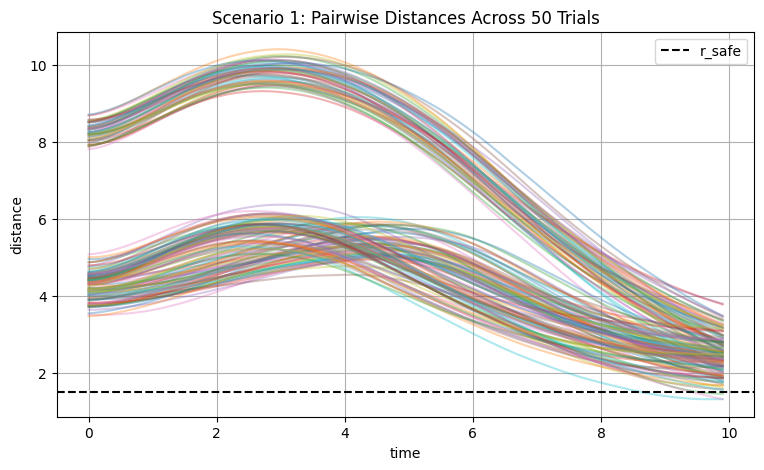

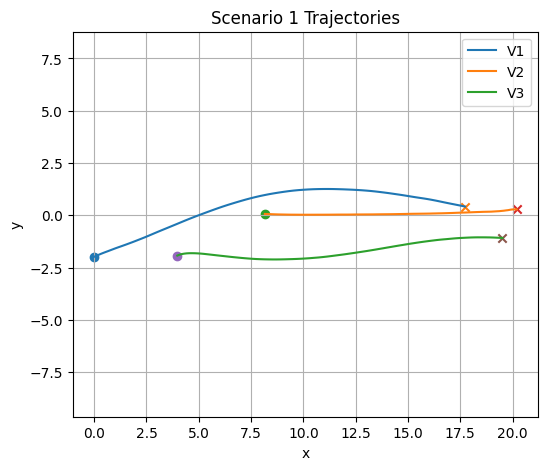

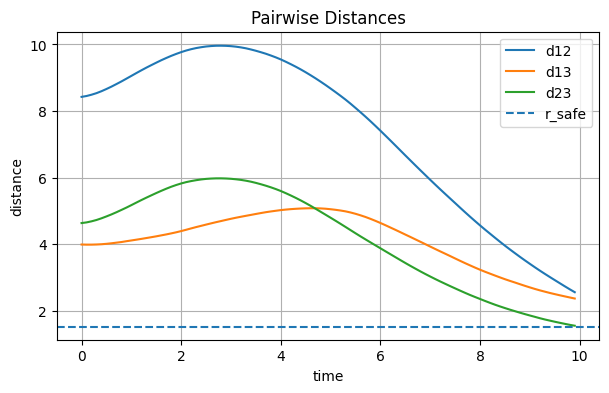

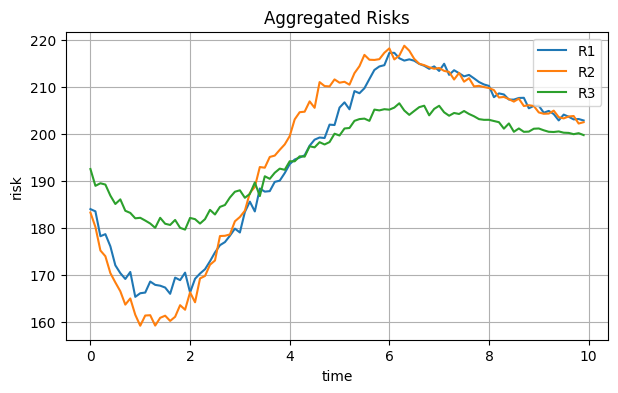


===== Scenario 2: Position Swap =====
0.0% done
0.16666666666666669% done
0.33333333333333337% done
0.5% done
0.6666666666666667% done
0.8333333333333334% done
1.0% done
1.1666666666666667% done
1.3333333333333335% done
1.5% done
1.6666666666666667% done
1.8333333333333333% done
2.0% done
2.166666666666667% done
2.3333333333333335% done
2.5% done
2.666666666666667% done
2.833333333333333% done
3.0% done
3.166666666666667% done
3.3333333333333335% done
3.5000000000000004% done
3.6666666666666665% done
3.833333333333333% done
4.0% done
4.166666666666666% done
4.333333333333334% done
4.5% done
4.666666666666667% done
4.833333333333333% done
5.0% done
5.166666666666667% done
5.333333333333334% done
5.5% done
5.666666666666666% done
5.833333333333333% done
6.0% done
6.166666666666667% done
6.333333333333334% done
6.5% done
6.666666666666667% done
6.833333333333333% done
7.000000000000001% done
7.166666666666667% done
7.333333333333333% done
7.5% done
7.666666666666666% done
7.8333333333333

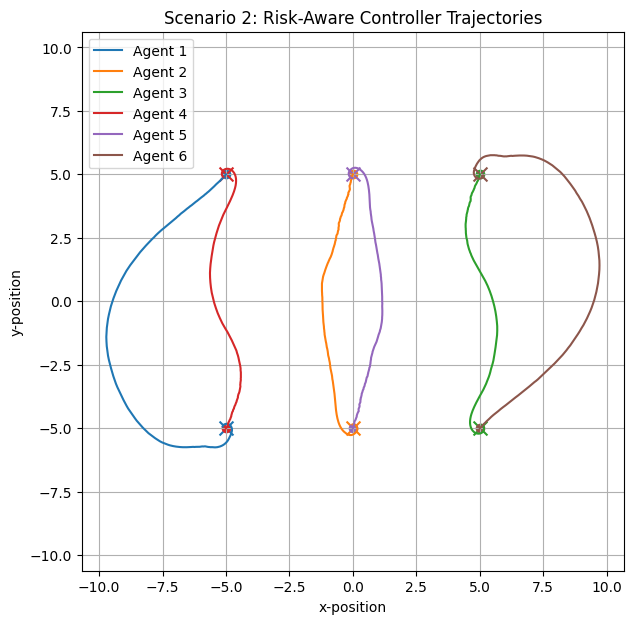

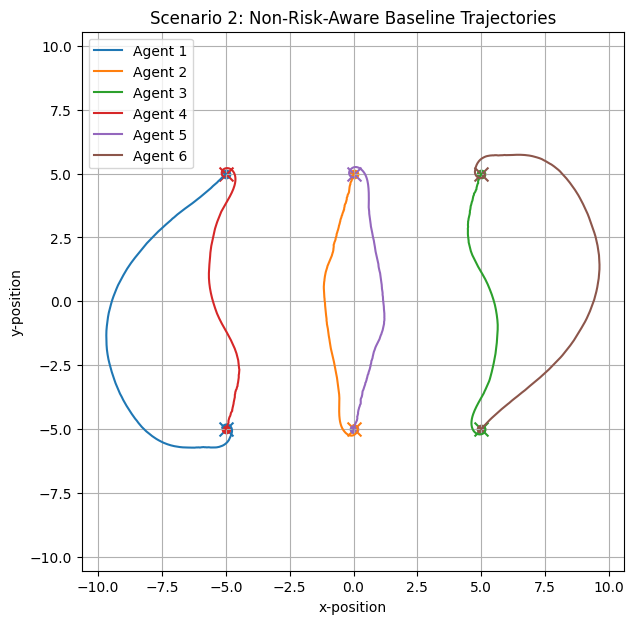

Animation progress: 11.0%
Animation progress: 22.0%
Animation progress: 33.0%
Animation progress: 44.0%
Animation progress: 54.9%
Animation progress: 65.9%
Animation progress: 76.9%
Animation progress: 87.9%
Animation progress: 98.9%
Animation progress: 100.0%


In [125]:
if __name__ == "__main__":

    os.makedirs("results", exist_ok=True)

    print("\n===== Scenario 1: Ramp Merge =====")

    summary_50 = run_50_trials(num_trials=50)
    print_50_trial_summary(summary_50)

    if summary_50["successful_trials"] > 0:
        dt = summary_50["last_results"]["dt"]
        r_safe = summary_50["last_results"]["r_safe"]
        plot_50_trial_distances(summary_50, dt, r_safe, "results/scenario1_50_trial_distances.png")

        plot_trajectories(summary_50["last_results"], "results/scenario1_trajectories")

        plot_pairwise_distances(summary_50["last_results"], "results/scenario1_pairwise_distances.png")

        plot_risks(summary_50["last_results"], "results/scenario1_risks.png")

    print("\n===== Scenario 2: Position Swap =====")

    risk_results = simulate_pos_swap(use_risk_aware=True)
    baseline_results = simulate_pos_swap(use_risk_aware=False)

    print_scenario2_results("Risk-aware controller", risk_results)
    print_scenario2_results("Non-risk-aware baseline", baseline_results)

    plot_pos_swap_trajectories(
        risk_results,
        "Scenario 2: Risk-Aware Controller Trajectories",
        "results/scenario2_risk_aware_trajectory.png"
    )

    plot_pos_swap_trajectories(
        baseline_results,
        "Scenario 2: Non-Risk-Aware Baseline Trajectories",
        "results/scenario2_baseline_trajectory.png"
    )

    display(animate_existing_pos_swap(risk_results))